# Feature Analysis for Hamiltonian Neural Koopman Operator

This notebook demonstrates how to extract and visualize nearly invariant components learned by the lifted Koopman representation. The structure is: model definition, data generation, training, feature extraction, and visualization.

## 1. Imports and plotting setup

The notebook relies on `functions.py` for shared utilities such as `odeint`, `geotorch`, `nn`, and energy-related helper functions. Please keep `functions.py` in the same folder as this notebook.

In [4]:
import math
import os
import timeit

import matplotlib.pyplot as plt
import numpy as np
import torch

from functions import *

# plt.rcParams["text.usetex"] = False
# plt.rcParams["mathtext.default"] = "regular"
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"]
# plt.rcParams["axes.unicode_minus"] = False
# plt.rcParams["ytick.direction"] = "in"
# plt.rcParams["xtick.direction"] = "in

D:\Anaconda\envs\zjd3.7.6\lib\site-packages\tqdm-4.64.0-py3.7.egg\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Orthogonal Koopman layer

The Koopman operator is represented by a linear layer constrained to be orthogonal. This constraint helps preserve the geometry of the lifted dynamics.

In [5]:
class K_Net(torch.nn.Module):
    def __init__(self, n_input, n_output):
        super(K_Net, self).__init__()
        self.recurrent_kernel = nn.Linear(n_input, n_output, bias=False)
        geotorch.orthogonal(self.recurrent_kernel, "weight")
        self.reset_parameters()

    def reset_parameters(self):
        M = self.recurrent_kernel.parametrizations.weight[0]
        self.recurrent_kernel.weight = M.sample("uniform")

    def forward(self, data):
        return self.recurrent_kernel(data)

## 3. Lift network and decoder

The lift network maps the original state into a higher-dimensional latent space. The decoder maps the lifted state back to the physical state space.

In [6]:
class lift_Net(torch.nn.Module):
    def __init__(self, n_input, n_hidden, n_output):
        super(lift_Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_output),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

        self.k = torch.tensor(2.5, requires_grad=True)
        self.v = torch.randn([4 + lift_d, q], requires_grad=True)

    def forward(self, data):
        return self.net(data)


class Decoder(nn.Module):
    def __init__(self, n_hidden):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4 + lift_d, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 4),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

    def forward(self, y):
        return self.net(y)

## 4. Kepler system

The Kepler system is used here as a low-dimensional Hamiltonian benchmark. The state is `(x, y, a, b)`, where `(x, y)` denotes position and `(a, b)` denotes velocity.

In [7]:
class kepler(nn.Module):
    dim = 4

    def forward(self, t, X):
        dx = torch.zeros_like(X)
        x, y, a, b = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
        dx[:, 0] = a
        dx[:, 1] = b
        dist = (x**2 + y**2) ** 1.5
        dx[:, 2] = -x / dist
        dx[:, 3] = -y / dist
        return dx

## 5. Generate training trajectory

We generate a short noisy trajectory for training and use the clean trajectory for later evaluation.

In [8]:
n_train = 100
initial_state = torch.tensor([[1.0, 0.0, 0.0, 0.9]])
time_grid = torch.linspace(0, 5, n_train)
true_y = odeint(kepler(), initial_state, time_grid, atol=1e-8, rtol=1e-8)[:, 0, :]

print(true_y.shape)

torch.Size([100, 4])


## 6. Hyperparameters

For the Kepler feature-generation experiment, the lifted dimension is `4 + lift_d`. The value of `D_in` is therefore set to `4 + lift_d`.

In [9]:
sigma = 0.03
lift_d = 19
q = 15
D_in = 4 + lift_d
H1 = 10 * D_in
D_out = 4 + lift_d

print("Lifted dimension:", D_in)

Lifted dimension: 23


## 7. Train the lifted Koopman model and save features

The objective contains four terms: one-step Koopman prediction error, reconstruction error, approximate spherical constraint, and orthogonality regularization for feature directions.

In [10]:
def generate_features(max_iters=10000, learning_rate=0.005, save_dir="./data/feature_data"):
    os.makedirs(save_dir, exist_ok=True)

    start = timeit.default_timer()
    torch.manual_seed(69)
    np.random.seed(369)

    model = K_Net(D_in, D_out)
    y = true_y + torch.from_numpy(np.random.normal(0, sigma, true_y.shape))
    g1 = lift_Net(4, 32, 4 + lift_d)
    Dec = Decoder(32)

    optimizer = torch.optim.Adam(
        [p for p in model.parameters()] +
        [p for p in g1.parameters()] +
        [g1.k, g1.v] +
        [p for p in Dec.parameters()],
        lr=learning_rate,
    )

    losses = []
    best_loss = float("inf")
    best_K = None
    best_enc = None

    for i in range(max_iters):
        lift_y = g1(y)
        dec_y = Dec(lift_y)
        X1, X2 = lift_y[:-1], lift_y[1:]

        v = g1.v / torch.sqrt(torch.sum(g1.v**2, dim=0))
        V = torch.mm(v.T, v) - torch.eye(q)

        loss = (
            torch.sum((X2 - model(X1)) ** 2)
            + torch.sum((dec_y - y) ** 2)
            + torch.sum((torch.sum(lift_y**2, dim=1) - g1.k) ** 2)
            + torch.sum(torch.mm(lift_y, v) ** 2)
            + torch.sum(V**2)
        )

        print(i, "loss=", loss.item())
        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()

        losses.append(loss.item())
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_K = model.recurrent_kernel.weight.detach().numpy()
            best_enc = {key: value.clone() for key, value in g1.state_dict().items()}

        if loss <= 1e-4:
            break

    stop = timeit.default_timer()
    K = best_K
    np.save(f"{save_dir}/koopman_{D_in}_{sigma}", K)

    g1.load_state_dict(best_enc)
    enc = g1(y).detach().numpy()
    np.save(f"{save_dir}/enc_{D_in}_{sigma}", enc)

    lift_y = g1(true_y)
    n_pred = 300
    Y = np.zeros([n_pred, len(K)])
    Y[0, :] = lift_y.detach().numpy()[0, :]
    for i in range(n_pred - 1):
        x = Y[i, :].reshape(-1, 1)
        Y[i + 1, :] = np.matmul(K, x).T[0]

    pred_y = Dec(torch.from_numpy(Y)).detach().numpy()

    print('Total time:', stop - start)
    return K, enc, pred_y, losses

Run the following cell to train the model. You may skip this cell and directly load the precomputed feature files in the next section.

In [11]:
# K, enc, pred_y, losses = generate_features(max_iters=10000)

## 8. Utility functions for feature analysis

In [12]:
def normalize(data):
    data = np.sort(np.abs(data))[::-1]
    return data / np.max(np.abs(data))


def check_orthogonal_initialization(dim=17):
    model = K_Net(dim, dim)
    K = model.recurrent_kernel.weight.detach().numpy()
    eigenvalue, featurevector = np.linalg.eig(K)
    print("Eigenvalues:", np.real(eigenvalue))

## 9. Plot temporal variance of learned components

This visualization compares the temporal variance of the conserved-like component `g_c` and several dominant learned components. 

In [13]:
def _component_variance_values(K, enc, mode="top"):
    eigenvalue, featurevector = np.linalg.eig(K)
    weight = np.real(featurevector[:, -1])
    quantity = np.sum(weight * enc, axis=1)

    if mode == "top":
        var_list = [np.std(enc[:, i]) ** 2 for i in range(len(K))]
        value_list = [np.std(quantity) ** 2]
        value_list += [var_list[i] for i in np.argsort(np.array(var_list))[::-1][:7]]
    else:
        value_list = [np.std(quantity) ** 2]
        value_list += [np.std(enc[:, i]) ** 2 for i in range(len(K))]
        value_list = value_list[:8]

    return [np.log(x) for x in value_list]


def plot_feature_variance():
    fontsize = 15
    ticksize = 12
    labels = ["g_c", "g_1", "g_2", "g_3", "g_4", "g_5", "g_6", "g_7"]
    color_list = ["k"] + ["gray" for _ in range(len(labels) - 1)]
    bar_width = 0.5

    fig = plt.figure(figsize=(10, 4))
    plt.subplots_adjust(left=0.07, bottom=0.15, right=0.98, top=0.9, hspace=0.95, wspace=0.25)

    plt.subplot(131)
    K = np.load("./data/feature_data/koopman_31_0.03_threebody.npy")
    enc = np.load("./data/feature_data/enc_31_0.03_threebody.npy")
    value_list = _component_variance_values(K, enc, mode="top")
    plt.bar(np.arange(len(labels)), value_list, color=color_list, width=bar_width)
    plt.ylim(-15, 0.5)
    plt.yticks([-15, 0], fontsize=ticksize)
    plt.xticks(np.arange(len(labels)), labels, fontsize=12)
    plt.xlabel("Component", fontsize=fontsize)
    plt.ylabel("log(Temporal Variance)", fontsize=fontsize, labelpad=-25)
    plt.title("Threebody", fontsize=fontsize)
    plt.scatter(np.arange(1), [-13], marker="*", color="red", s=50, label="Hamiltonian")
    plt.legend(fontsize=fontsize, loc=4, frameon=True)

    plt.subplot(132)
    K = np.load("./data/feature_data/koopman_7_0.0_kepler.npy")
    enc = np.load("./data/feature_data/enc_7_0.0_kepler.npy")
    value_list = _component_variance_values(K, enc, mode="top")
    plt.bar(np.arange(len(labels)), value_list, color=color_list, width=bar_width)
    plt.ylim(-8, 0.5)
    plt.yticks([-8, 0], fontsize=ticksize)
    plt.xticks(np.arange(len(labels)), labels, fontsize=12)
    plt.xlabel("Component", fontsize=fontsize)
    plt.ylabel("log(Temporal Variance)", fontsize=fontsize, labelpad=-20)
    plt.scatter(np.arange(1), [-7.5], marker="*", color="red", s=50, label="Hamiltonian")
    plt.title("Kepler", fontsize=fontsize)
    plt.legend(fontsize=fontsize, loc=4, frameon=True)

    plt.subplot(133)
    K = np.load("./data/feature_data/koopman_84_0.03_kdv.npy")
    enc = np.load("./data/feature_data/enc_84_0.03_kdv.npy")
    value_list = _component_variance_values(K, enc, mode="all")
    plt.bar(np.arange(len(labels)), value_list, color=color_list, width=bar_width)
    plt.ylim(-17, 0.5)
    plt.yticks([-17, 0], fontsize=ticksize)
    plt.xticks(np.arange(len(labels)), labels, fontsize=12)
    plt.xlabel("Component", fontsize=fontsize)
    plt.ylabel("log(Temporal Variance)", fontsize=fontsize, labelpad=-25)
    plt.scatter(np.arange(1), [-16.5], marker="*", color="red", s=50, label="Hamiltonian")
    plt.title("KdV", fontsize=fontsize)
    plt.legend(fontsize=fontsize, loc=4, frameon=True)

    plt.show()

Run the final cell to reproduce the comparison figure. Make sure the required files exist under `./data/feature_data/`.

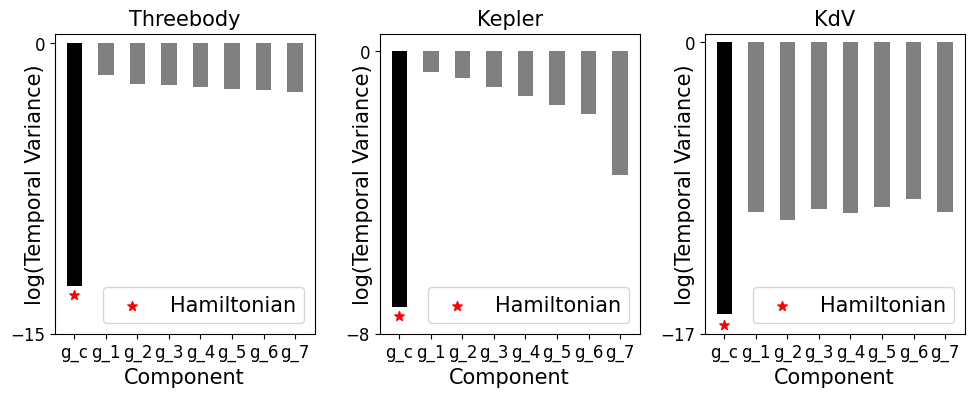

In [14]:
plot_feature_variance()